# Ratio-метрики и линеаризация 

Статья: https://github.com/avito-tech/applied_statistics/blob/main/Ratio%20metrics.ipynb

Пример: считаем конверсию из просмотра объявление в написание 
$$
\text{Ratio} = \frac{\text{количество написаний}}{\text{количество просмотров объявлений}} = \frac{X_1 + ... + X_n}{Y_1 + ... + Y_n} \\
\ 
$$   

Тут **единица разбиения - просмотр объявления**. Поэтому когда мы составим выборку, у нас наблюдения будут зависимы 

> Можно просто написать Bootstrap и все посчитать, но работать он будет за $O(N * B)$, что небыстро. Поэтому разбиремся, как это линеаризовать

$$\underbrace{1 + 1 + 0 + 0 + 0}_{\text{user 1}} + \underbrace{1 + 1 + 1 + 1 + 1}_{\text{user 2}} + ...$$

Любую обычную поюзерную метрику можно написать как Ratio:
$$\frac{X_1 + ... + X_n}{1 + ... + 1} = \frac{\sum{X}}{\sum{U}}$$

Мощность при использовании Ratio метрики будет выше, чем мощность при сравнении средних

- в ratio метрике в текущем примере вы сравниваете $p^T\ vs.\ p^C$ (так как $\dfrac{M}{O} = \dfrac{O \cdot p}{O} = p$)


- А в t-test происходит сравнение $M^T\ vs.\ M^C$ или ${O^T \cdot p^T}\ vs.\ {O^C \cdot p^C}$, что что является более шумной величиной из-за случайной величины O

В реальных задачах все то же самое: вы убираете из данных часть шума, обусловленного знаменателем. Тем самым вы получаете менее шумную метрику.

> А чем меньше шума, тем меньше дисперсия. То есть, хвосты распределения менее тяжелые, доверительный интервал более узкий и становится ближе к реальному, то есть чаще будем принимать верно альтернативную гипотезу, и мощность увеличится

---

**Главная проблема ratio-метрики — вы добавляете знаменатель к вашей метрике, который также может поменяться от вашего изменения на сайте.**

И в этот момент результат $H_1: \mathbb{E} \dfrac{\sum M^T}{\sum O^T} - \mathbb{E} \dfrac{\sum M^C}{\sum O^C} > 0$ будет не согласован с    
$H_1: \mathbb{E} M^T -  \mathbb{E} M^C > 0$


Например, в нашей задаче мы могли бы вместо покраса кнопки в красный цвет сделать неадекватное изменение: зашел в чат из объявления -> тебя заблокировали. Конверсия в тестовой группе была бы равна 1. Но вот число пользователей, а соответственно, и число заходов на страницу объявления $O$ сильно уменьшилось бы (все бы перестали пользоваться Авито)

Поэтому:
- Если вы уверены, что не повлияли на знаменатель, то просто проверяете изменение ratio-метрики
- Если же есть шанс затронуть знаменатель, то вы проверяете ratio-метрику, а потом знаменатель с помощью ttest

---

**Линеаризация**

Используем то же разложение в ряд Тейлора в точке $(\mathbb{E} X, \mathbb{E}Y)$

$$Ratio = \frac{X_1 + ... + X_n}{Y_1 + ... + Y_n} = \dfrac{\overline{X}}{\overline{Y}} \approx \dfrac{\mathbb{E} X}{\mathbb{E} Y} + \dfrac{1}{\mathbb{E} Y}\left(\overline{X} - \dfrac{\mathbb{E} X}{\mathbb{E} Y}\overline{Y} \right) = \\ \\
\ 

= \frac{1}{n} \sum \ \dfrac{\mathbb{E} X}{\mathbb{E} Y} + \dfrac{1}{\mathbb{E} Y}\left(X_i - \dfrac{\mathbb{E} X}{\mathbb{E} Y}Y_i \right) = \frac{1}{n} \sum Z_i$$

Что мы получили? Теперь наша Ratio метрика это просто среднее $Z_i$, которые независимы. И мы можем сделать обычный ttest. Конечно, мы не знаем $\mathbb{E}X$ и $\mathbb{E}Y$, но можем их заменить на оценки $\overline{X}$, $\overline{Y}$, которые по ЗБЧ сходятся к матожиданию

> И здесь мы даже не пересчитываем новую дисперсию 

---

Важный момент 

$$
\mathbb{E} \dfrac{\sum M}{\sum O} = \mathbb{E} \dfrac{\overline M}{ \overline O} \neq \mathbb{E} \dfrac{M}{O}
$$

Где $\mathbb{E} \dfrac{M}{O}$ - это мы для каждого пользователя посчитали его конверсию и потом взяли среднее всех этих конверсий. Обычно эта метрика (среднее средних) не совсем верна 

> Почему? Так как рост $\mathbb{E} \dfrac{\sum M}{\sum O}$ на $X\%$ эквивалентен росту $\mathbb{E} M$ на $X \%$ (вы увеличили число чатов на X процентов), что вас и интересует на самом деле. А для второй дроби вы утверждать такое не можете.

In [1]:
import numpy as np 
import pandas as pd
from scipy import stats

import math

import matplotlib.pyplot as plt
import seaborn as sns
import random

from statsmodels.stats.power import tt_solve_power

from tqdm import tqdm

from statsmodels.graphics.gofplots import qqplot

from statsmodels.stats.proportion import proportion_confint

from collections import namedtuple, defaultdict

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 21
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

In [ ]:
def plot_pvalue_distribution(dict_pvalues):
    """Рисует графики распределения p-value."""
    X = np.linspace(0, 1, 1000)
    for name, pvalues in dict_pvalues.items():
        # Эмпирическая CDF для pvalue
        Y = [np.mean(pvalues < x) for x in X]
        plt.plot(X, Y, label=name)

    plt.plot([0, 1], [0, 1], '--k', alpha=0.8)
    plt.title('Оценка распределения p-value', size=16)
    plt.xlabel('p-value', size=12)
    plt.legend(fontsize=12)
    plt.grid()
    plt.show()

100%|██████████| 10000/10000 [00:10<00:00, 955.47it/s]


Type I: 0.265, CI = [0.257, 0.274]


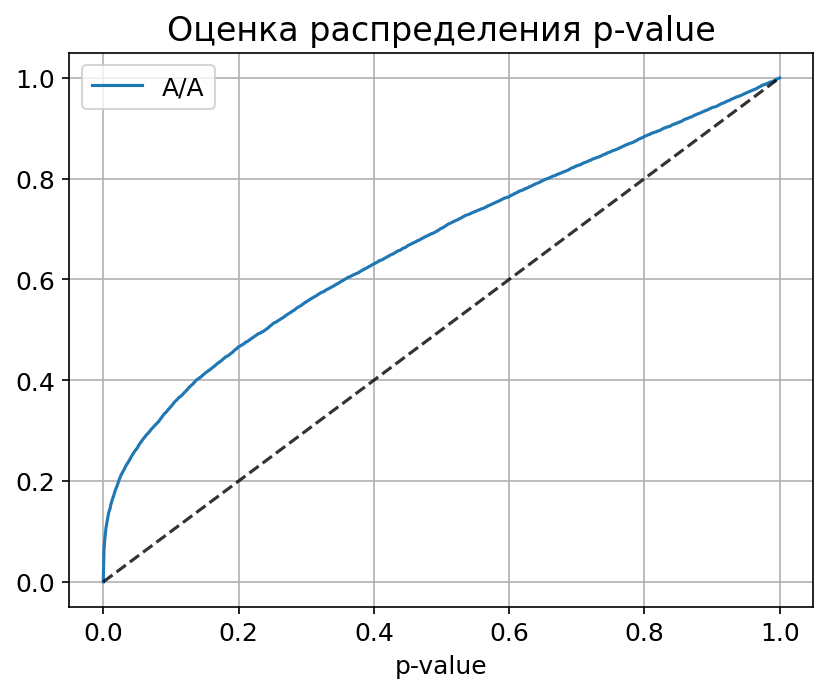

In [6]:
# Кейс: измеряем метрику среднее количество написния по объявлению
# Проверим, что обычный ttest на Ratio метрике дает очень высокий FPR
# Так получилось, так как наблюдения в выбоку зависимы межу собой

# Генерируем распределение:
# 0, если пользователь не написал по объявлению
# 1, если написал
# То есть для каждого пользователя будет последователньость 0 и 1
def generate_incorrect_sample(user_size, p=0.3):
    # Всего у нас sample_size пользователей
    # На сколько объявлений перешел каждый пользователь
    O_array = stats.norm(loc=10, scale=1).rvs(user_size).astype(int)

    # Процент объявлений, по котормы перешел каждый пользователь
    p_array = stats.uniform().rvs(user_size)

    # размер выборки
    sample_size = np.sum(O_array)
    # на сколько объявлений суммарно перешли пользователи
    M_sum = np.sum((O_array * p_array).astype(int))

    # генерируем выборку из 0 и 1
    sample = [1] * M_sum + [0] * (sample_size - M_sum)

    return sample

# Делаем АА тест и считаем Type I

np.random.seed(42)

alpha=0.05
user_size = 1000

pvalues_dict = defaultdict(list)

bad_cnt = 0
N = 10000
for i in tqdm(range(N)):
    # Генерирую выборку теста и контроля
    control    = generate_incorrect_sample(user_size)
    test = generate_incorrect_sample(user_size)

    # Запускаю критерий и считаю p-value
    pvalue = stats.ttest_ind(test, control, equal_var=True).pvalue

    pvalues_dict["A/A"].append(pvalue)
    
    # Проверяю, что pvalue < alpha
    bad_cnt += (pvalue < alpha)


ci_left, ci_right = proportion_confint(count=bad_cnt, nobs=N, alpha=0.05, method='wilson')

print(f"Type I: {bad_cnt / N:.3f}, CI = [{ci_left:.3f}, {ci_right:.3f}]")

plot_pvalue_distribution(pvalues_dict)

100%|██████████| 10000/10000 [00:07<00:00, 1396.50it/s]


Type I: 0.047, CI = [0.043, 0.052]


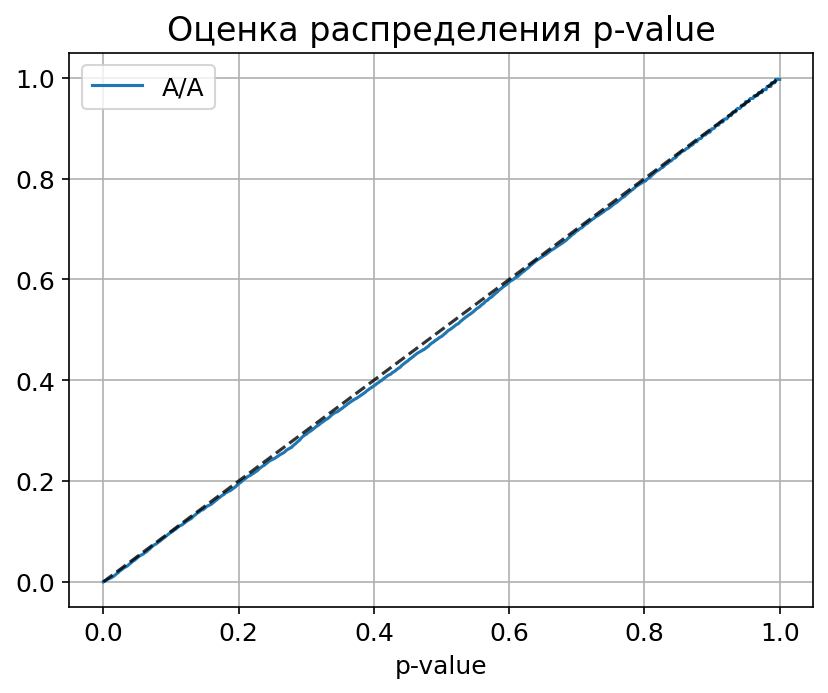

In [8]:
# Решение 1: будем считать не конверсию из просмотра в написание 
# а увеличение количества чатов

def generate_group_sample(group_size):
    O_array = stats.norm(loc=10, scale=1).rvs(group_size).astype(int)
    p_array = stats.uniform().rvs(group_size)

    M_array = (O_array * p_array).astype(int)

    return {
        "O_array": O_array, # Opened
        "M_array": M_array # Messaged
    }

np.random.seed(42)
alpha=0.05
user_size = 1000

pvalues_dict = defaultdict(list)

bad_cnt = 0
N = 10000
for i in tqdm(range(N)):
    # Генерирую выборку теста и контроля
    control = generate_group_sample(user_size)
    test = generate_group_sample(user_size)

    # Запускаю критерий и считаю p-value
    pvalue = stats.ttest_ind(control['M_array'], test['M_array'], equal_var=True).pvalue

    pvalues_dict["A/A"].append(pvalue)
    
    # Проверяю, что pvalue < alpha
    bad_cnt += (pvalue < alpha)


ci_left, ci_right = proportion_confint(count=bad_cnt, nobs=N, alpha=0.05, method='wilson')

print(f"Type I: {bad_cnt / N:.3f}, CI = [{ci_left:.3f}, {ci_right:.3f}]")

plot_pvalue_distribution(pvalues_dict)

In [11]:
# Решение 2: bootstrap 

def get_bootstrap_ci(M_control, M_test, O_control, O_test, alpha=0.05):
    n_iter = 1000

    statistic_array = []
    control_indices = np.random.choice(np.arange(len(O_control)), size=(n_iter, len(O_control)), replace=True)
    test_indices = np.random.choice(np.arange(len(O_test)), size=(n_iter, len(O_test)), replace=True)

    boot_M_control = M_control[control_indices]
    boot_O_control = O_control[control_indices]
    boot_M_test = M_test[test_indices]
    boot_O_test = O_test[test_indices]

    statistic_array = np.sum(boot_M_test, axis=1) / np.sum(boot_O_test, axis=1) - np.sum(boot_M_control, axis=1) / np.sum(boot_O_control, axis=1)

    statistic_array = statistic_array.ravel()

    ci_left, ci_right = np.quantile(statistic_array, [alpha / 2, 1 - alpha / 2])

    return ci_left, ci_right

np.random.seed(42)
alpha=0.05
user_size = 1000

bad_cnt = 0
N = 10000
for i in tqdm(range(N)):
    # Генерирую выборку теста и контроля
    control = generate_group_sample(user_size)
    test = generate_group_sample(user_size)

    # Делаю Bootstrap
    ci_left, ci_right = get_bootstrap_ci(control['M_array'],  test['M_array'], control['O_array'], test['O_array'], alpha=alpha)

    # Запускаю критерий
    bad_cnt += (0 if ci_left < 0 < ci_right else 1)


ci_left, ci_right = proportion_confint(count=bad_cnt, nobs=N, alpha=0.05, method='wilson')

print(f"Type I: {bad_cnt / N:.3f}, CI = [{ci_left:.3f}, {ci_right:.3f}]")

100%|██████████| 10000/10000 [01:00<00:00, 165.97it/s]

Type I: 0.054, CI = [0.050, 0.059]


In [14]:
# Сравним мощность Bootstrap и ttest
# Получили, что у Bootstrap мощность выше

def generate_group_sample(group_size, p=0.01):
    O_array = stats.norm(loc=50, scale=5).rvs(group_size).astype(int)

    p_array = stats.norm(loc=p, scale=p/10).rvs(group_size)
    p_array = np.clip(p_array, 0, 1)

    M_array = (O_array * p_array).astype(int)

    return {
        "O_array": O_array, # Opened
        "M_array": M_array # Messaged
    }

# A/B тест, сравниваем мощности

np.random.seed(42)
alpha=0.05
group_size = 1000

ttest_power_cnt = 0
bootstrap_power_cnt = 0
N = 1000
for i in tqdm(range(N)):
    # Генерирую выборку теста и контроля
    control = generate_group_sample(group_size, p=0.1)
    test = generate_group_sample(group_size, p=0.101)

    # Делаю ttest: используем только информацию о среднем количестве написаний по объявлению
    pvalue = stats.ttest_ind(control['M_array'], test['M_array'], equal_var=False).pvalue
    ttest_power_cnt += (pvalue < alpha)

    # Делаю Bootstrap
    ci_left, ci_right = get_bootstrap_ci(control['M_array'],  test['M_array'], control['O_array'], test['O_array'], alpha=alpha)
    bootstrap_power_cnt += (ci_left > 0)


ci_left_ttest, ci_right_ttest = proportion_confint(count=ttest_power_cnt, nobs=N, alpha=0.05, method='wilson')
ci_left_bootstrap, ci_right_bootstrap = proportion_confint(count=bootstrap_power_cnt, nobs=N, alpha=0.05, method='wilson')

print(f"Ttest Power: {ttest_power_cnt / N:.3f}, CI = [{ci_left_ttest:.3f}, {ci_right_ttest:.3f}]")
print(f"Bootstrap Power: {bootstrap_power_cnt / N:.3f}, CI = [{ci_left_bootstrap:.3f}, {ci_right_bootstrap:.3f}]")

100%|██████████| 1000/1000 [00:06<00:00, 160.96it/s]

Ttest Power: 0.296, CI = [0.269, 0.325]
Bootstrap Power: 0.509, CI = [0.478, 0.540]


In [17]:
# Способ 3: Линеаризация 

def linearize(num, den):
    E_num = np.mean(num)
    E_den = np.mean(den)
    
    return E_num / E_den + 1 / E_den * (num - E_num / E_den * den)

# A/A тест, сравниваем FPR

np.random.seed(42)
alpha=0.05
group_size = 1000

linear_cnt = 0
bootstrap_cnt = 0
N = 1000
for i in tqdm(range(N)):
    # Генерирую выборку теста и контроля
    control = generate_group_sample(group_size)
    test = generate_group_sample(group_size)

    # Делаю Bootstrap
    ci_left, ci_right = get_bootstrap_ci(control['M_array'],  test['M_array'], control['O_array'], test['O_array'], alpha=alpha)
    bootstrap_cnt += (ci_left > 0 or ci_right < 0)

    # Делаю ttest с линеаризованными Ratio метриками
    control_linear = linearize(control['M_array'], control['O_array'])
    test_linear = linearize(test['M_array'], test['O_array'])
    pvalue = stats.ttest_ind(control_linear, test_linear, equal_var=False).pvalue
    linear_cnt += (pvalue < alpha)


ci_left_linear, ci_right_linear = proportion_confint(count=linear_cnt, nobs=N, alpha=0.05, method='wilson')
ci_left_bootstrap, ci_right_bootstrap = proportion_confint(count=bootstrap_cnt, nobs=N, alpha=0.05, method='wilson')

print(f"Ttest Power: {linear_cnt / N:.3f}, CI = [{ci_left_linear:.3f}, {ci_right_linear:.3f}]")
print(f"Bootstrap Power: {bootstrap_cnt / N:.3f}, CI = [{ci_left_bootstrap:.3f}, {ci_right_bootstrap:.3f}]")

100%|██████████| 1000/1000 [00:06<00:00, 162.31it/s]

Ttest Power: 0.000, CI = [0.000, 0.004]
Bootstrap Power: 0.000, CI = [0.000, 0.004]
